# Evaluation of the new framework

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import MultiModalEncoder, ClinicalLinkageModule, concat_modality_embeddings
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe, make_patient_map, RegularizationModule
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.utils.model_saving import *
from gbmhackathon.training.loops import modality_wise_contrastive_learning, new_predictive_learning, build_run_name
from gbmhackathon.training.cv import *
from gbmhackathon.utils.analysis import *
from gbmhackathon.viz.viz_experiment import *
from gbmhackathon.s3_loader import load_s3

import os, time
from copy import deepcopy
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
# To investigate gradients


import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

In [3]:
torch.set_num_threads(32)
torch.get_num_threads()

32

In [4]:
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

## Dataset preparation

In [5]:
ALL_POSSIBLE_EMBS = ["025-03-22_12-27_phikon_emb_V1.pkl",
                    "2025-03-23_18-32_spatial_emb_V1.pkl",
                    "2025-03-30_14-23_clinical_emb_V1.pkl",
                    "2025-04-05_13-40_wes_emb_V1.pkl",
                    "2025-04-26_16-02_connectivities_spatial_V1.pkl",
                    "2025-05-03_10-15_bulk_emb_V1.pkl",
                    "2025-05-04_02-35_scRNA_emb_V1.pkl",
                    "2025-05-25_14-36_new_clinical_emb_V1.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_mds.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_pca.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_umap.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_mds.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_pca.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_umap.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_mds.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_pca.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_umap.pkl",
                    "2025-06-01_15-11_wes_emb_V1_mds.pkl",
                    "2025-06-01_15-11_wes_emb_V1_pca.pkl",
                    "2025-06-01_15-11_wes_emb_V1_umap.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_mds.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_pca.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_umap.pkl",
                    "2025-06-01_21-03_raw_spatial_emb_pca.pkl",
                    "2025-06-01_22-10_raw_spatial_emb_umap.pkl",
                    "2025-06-02_21-09_raw_scRNA_emb_pca.pkl",
                    "2025-06-02_22-50_raw_scRNA_emb_umap.pkl",
                    "embeddings_HnE_OptimusH0.pkl"]

### You can choose any embedding from the above

In [6]:
name_emb_dict = {#"hne":"embeddings_HnE_OptimusH0.pkl",
# "spatial":"2025-06-01_22-10_raw_spatial_emb_umap.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-06-01_18-36_raw_bulk_emb_pca.pkl",
"scRNA":"2025-06-02_21-09_raw_scRNA_emb_pca.pkl"
                }
pkl_storage_folder = "embedding_V1"

In [7]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=1.0, normalize=True)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 742 #582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cpu 
Using device: cpu
Normalization applied successfully
By keeping 100.00% of dropout augmented samples we went from:
94 dropout samples (45.19% dropout in dataset) -- to --> 94 dropout samples (45.19% dropout in dataset)
Dataset size: 208


### To make a batch of True patient samples only (no dropout)

In [8]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

### Needed to know the size of the inputs (it is used later on to define model configurations)

In [9]:
raw_emb = next(iter(dataloader))[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

clinical torch.Size([208, 20])
wes torch.Size([208, 1790])
bulk torch.Size([208, 60])
scRNA torch.Size([208, 64])


### Patient map is used by the contrastive loss to identify dropout and true samples which are from the same original patient

In [10]:
patient_map = make_patient_map(dataset)

### Configuration of the MultiModalEncoder (see gbmhackathon/models/mme.py)

In [11]:
def adapt_base_config(base_cfg, input_size):
    base_copy = deepcopy(base_cfg)
    base_copy["layers"] = [input_size] + base_copy["layers"]
    return base_copy

In [12]:
out = 32
norm_fn = nn.BatchNorm1d
smoothing_fn = SmoothingFunction(bound=-50, slope=0.1, rate=-5)
dropout = 0.3
layers = [1024,512,128]
act_fn = [nn.GELU] * (len(layers) - 1) + [None]
base_cfg = {"layers": [512,128,out],
        "dropout": dropout,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

hne_cfg = {"layers": [512,128,out],
        "dropout": dropout,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

clinical_cfg = {"layers": [256,128,out],
        "dropout": dropout,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

spatial_cfg = {"layers": [256,128,out],
        "dropout": dropout,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

wes_cfg = {"layers": [512,128,out],
        "dropout": dropout,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

rna_cfg = {"layers": [1024,256,out], #[1024,128,512,128,out],
        "dropout": dropout,
        "act_fn":act_fn, #[nn.GELU, nn.GELU, nn.GELU, nn.GELU, smoothing_fn],
        "norm_layer":norm_fn,
        "device":device}


# hne_cfg = adapt_base_config(hne_cfg, inpute_size_dict["hne"])
clinical_cfg = adapt_base_config(clinical_cfg, inpute_size_dict["clinical"])
# spatial_cfg = adapt_base_config(spatial_cfg, inpute_size_dict["spatial"])
wes_cfg = adapt_base_config(wes_cfg, inpute_size_dict["wes"])
bulk_cfg = adapt_base_config(rna_cfg, inpute_size_dict["bulk"])
sc_cfg = adapt_base_config(rna_cfg, inpute_size_dict["scRNA"])

In [13]:
mme_bulk_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": bulk_cfg}

mme_hne_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": hne_cfg}

mme_sc_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": sc_cfg}

mme_wes_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": wes_cfg}

mme_clinical_cfg = {"net_type": "mlp",
                "device": device,
                "net_config": clinical_cfg}

mme_spatial_cfg = {"net_type": "mlp",
                "device": device,
                "net_config": spatial_cfg}

In [14]:
mme_cfg = {#"hne_cfg":mme_hne_cfg, 
           "clinical_cfg":mme_clinical_cfg, 
           "wes_cfg":mme_wes_cfg, 
           # "spatial_cfg":mme_spatial_cfg,
           "bulk_cfg":mme_bulk_cfg,
          "sc_cfg":mme_sc_cfg}

### Configuration of the Regularizer (see gbmhackathon/models/mme.py)

In [15]:
regularizer_cfg = {"reg_coeff":0.01,
        "use_variance":True,
        "var_coeff":1.0,
        "use_covariance":True,
        "cov_coeff":1.0,
        "var_gamma":1.0,
        "var_eps":1e-4,
}

### Instantiation of training settings: model, optimizer, scheduler, epochs, learning rate.

In [16]:
mme = instantiate(mme_cfg,MultiModalEncoder)

EPOCHS_I = 50
base_lr_I = 1e-3
eta_min_coef = 0.05
scheduler_I_class = torch.optim.lr_scheduler.CosineAnnealingLR
scheduler_I_cfg = {"T_max":EPOCHS_I,
                  "eta_min":"dynamic"}

contrastive_loss_cfg = {"modalities":list(name_emb_dict.keys()),
                        "patient_map":patient_map,
                        'mode':'modality_scale',
                        "temperature":0.05,
                        "similarity":'nt-xent',
                        "use_all_positives":False,
                        "alpha":0,
                        "bound":-50,
                        "slope":0.1,
                        "rate":-5,
                        "warn":False,
                       "smoothing_func":False}

# Optimization for Phase I
optimizer_I = Adam(mme.parameters(), lr=base_lr_I)
scheduler_I_cfg["optimizer"] = optimizer_I
if "eta_min" in scheduler_I_cfg.keys():
    if scheduler_I_cfg["eta_min"] == "dynamic":
        scheduler_I_cfg["eta_min"] = eta_min_coef * base_lr_I
scheduler_I = instantiate(scheduler_I_cfg, scheduler_I_class)

contrastive_loss_fn = instantiate(contrastive_loss_cfg, RegularizedInfoNCELoss)

modalities = next(iter(dataloader))[2].keys()
    
# A contrastive loss module per modality
modality_contrastive_loss_fn = {}
for modality in modalities:
    contrastive_loss_cfg_mod = contrastive_loss_cfg.copy()
    contrastive_loss_cfg_mod['modalities'] = [modality]
    modality_contrastive_loss_fn[modality] = instantiate(contrastive_loss_cfg_mod, RegularizedInfoNCELoss)

# An optimizer per modality
modality_optimizers = {modality:Adam(mme.modality_net_map[modality].parameters(), lr=base_lr_I) for modality in modalities}

# A scheduler per modality
modality_schedulers = {}
for modality in modalities:
    # Same schedule for all modalities for now, but it can be configurable
    scheduler_cfg = scheduler_I_cfg.copy()
    scheduler_cfg["optimizer"] = modality_optimizers[modality]
    if "eta_min" in scheduler_I_cfg.keys():
        if scheduler_cfg["eta_min"] == "dynamic":
            scheduler_cfg["eta_min"] = eta_min_coef * base_lr_I
    modality_schedulers[modality] = instantiate(scheduler_cfg, scheduler_I_class)

# A regularization method per modality
regularizer_dict = {}
for modality in modalities:
    regularizer_dict[modality] = instantiate(regularizer_cfg, RegularizationModule)

Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found


### Training loop for contrastive phase

EPOCH 1 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.0197
EPOCH 2 AVERAGE TOTAL LOSS ACROSS MODALITIES: 6.1688
EPOCH 3 AVERAGE TOTAL LOSS ACROSS MODALITIES: 5.6602
EPOCH 4 AVERAGE TOTAL LOSS ACROSS MODALITIES: 5.3500
EPOCH 5 AVERAGE TOTAL LOSS ACROSS MODALITIES: 5.0766
EPOCH 6 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.8369
EPOCH 7 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.6628
EPOCH 8 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.5268
EPOCH 9 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.4138
EPOCH 10 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.3166
EPOCH 11 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.2258
EPOCH 12 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.1453
EPOCH 13 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.0745
EPOCH 14 AVERAGE TOTAL LOSS ACROSS MODALITIES: 4.0134
EPOCH 15 AVERAGE TOTAL LOSS ACROSS MODALITIES: 3.9563
EPOCH 16 AVERAGE TOTAL LOSS ACROSS MODALITIES: 3.9055
EPOCH 17 AVERAGE TOTAL LOSS ACROSS MODALITIES: 3.8586
EPOCH 18 AVERAGE TOTAL LOSS ACROSS MODALITIES: 3.8156
EPOCH 19 AVERAGE TOTAL LOSS ACROSS MO

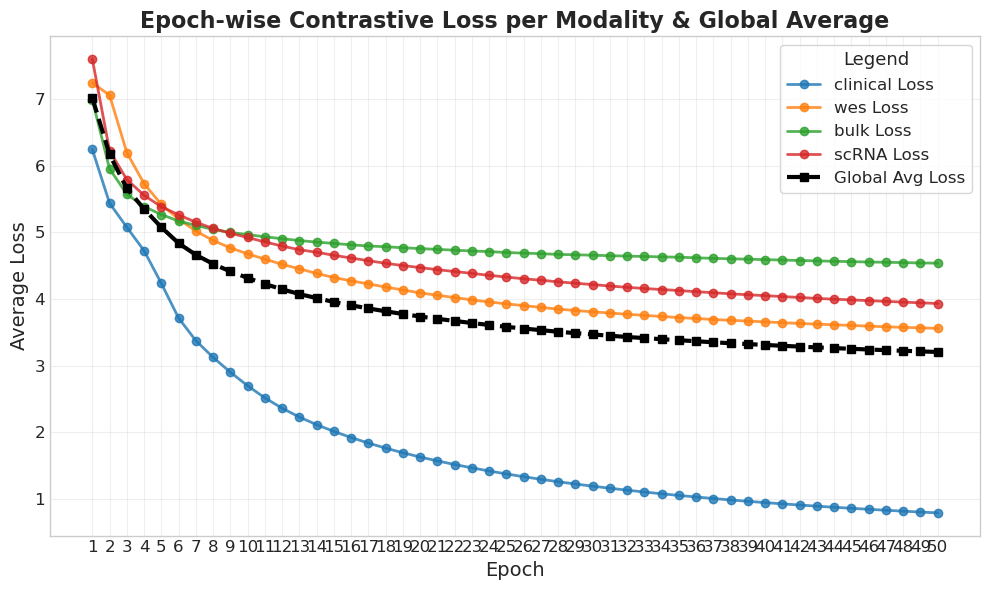

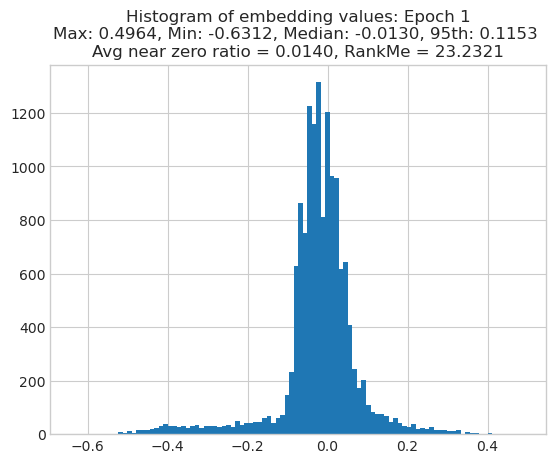

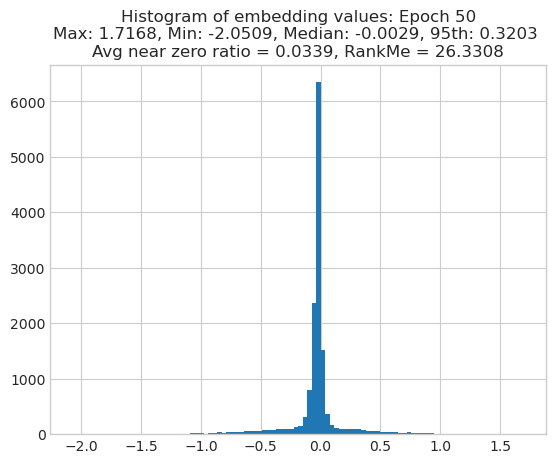

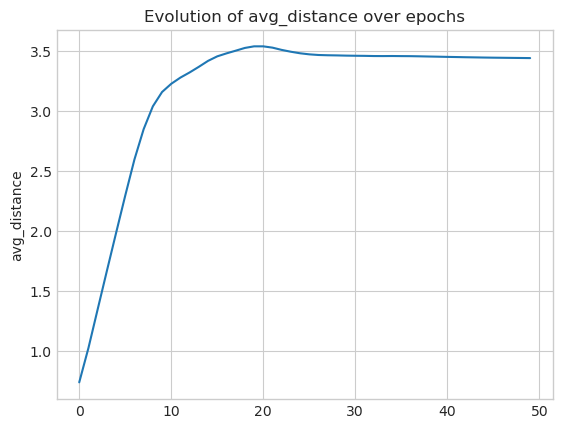

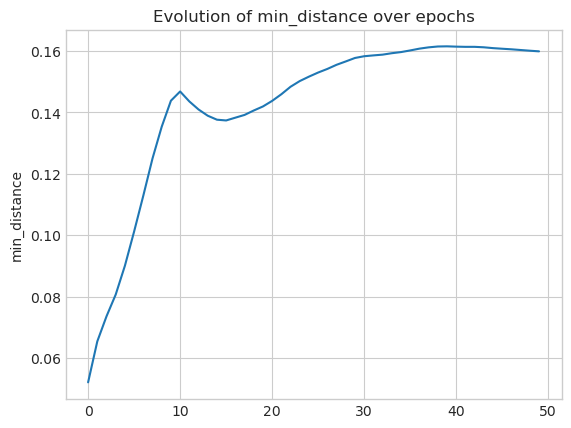

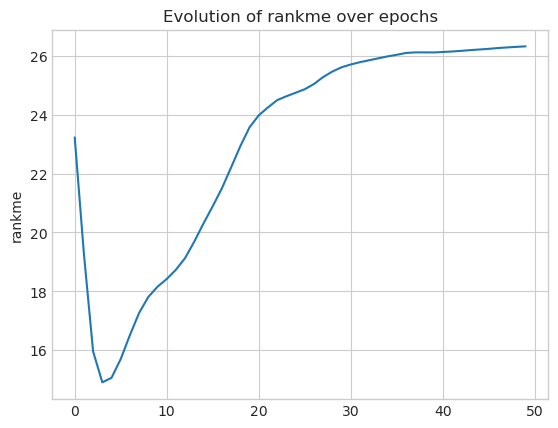

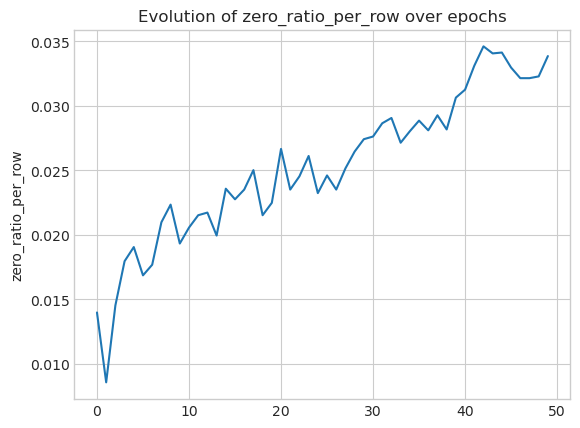

In [17]:
modality_wise_contrastive_learning(mme, 
                                   dataloader, 
                                   EPOCHS_I, 
                                   base_lr_I,
                                   modality_optimizers, 
                                   modality_contrastive_loss_fn, 
                                   modality_schedulers,
                                   regularizer_dict,
                                   batch_all=batch_all,
                                   make_gifs=False,
                                   analyze_emb=True)

## Save MultiModalEncoder

In [18]:
save_model(mme, '../saved_models/new_noFoundation_mme.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/new_noFoundation_mme.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_noFoundation_mme.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


(PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/new_noFoundation_mme.ckpt'),
 PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_noFoundation_mme.ckpt'))

## Use the trained MME to compute and save representations of true patient samples to use for the clinical linkage phase

In [19]:
run_name = build_run_name(
    model=mme,
    epochs=EPOCHS_I,
    base_lr=base_lr_I,
    eta_min_coef=eta_min_coef,
    scheduler_class=scheduler_I_class,
    scheduler_cfg=scheduler_I_cfg,
    contrastive_loss_cfg=contrastive_loss_cfg,
    modality_list=list(name_emb_dict.keys())
)

In [20]:
mme_emb_dict = mme(batch_all[2]) # Retrieves X_dict
folder = "mme_embeddings_no_foundation"
save_path = f"{folder}/{run_name}.pkl"
os.makedirs(folder, exist_ok=True)

with open(save_path, "wb") as f:
    pkl.dump(mme_emb_dict, f)

# Set everything up for clinical linkage phase
We can choose to remove dropout or not by instantiating another dataset

In [21]:
dataset_II = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=0.0, normalize=True)
print(f"Dataset size: {len(dataset_II)}")

cas 2 : device reconnu : cpu 
Using device: cpu
Normalization applied successfully
Dataset size: 114


### Configuration of the clinical linkage module

In [22]:
dropout = 0.3
layers = [out*len(mme_cfg),16]
act_fn = [nn.GELU] * (len(layers) - 1) + [None]
norm_fn = nn.BatchNorm1d
reg_head_cfg = {"layers": layers + [1],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}
binary_clf_head_cfg = {"layers": layers + [2],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}
multi_clf_head_cfg = {"layers": layers + [3],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

In [23]:
os_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
pfs_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
recurrency_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": binary_clf_head_cfg}
mgmt_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": multi_clf_head_cfg}

In [24]:
# ATTENTION !!!! MUST BE THIS EXACT ORDER FOR PREDICTIVE TASKS: 
# ['os_years', 'pfs_years', 'largest_diameter_of_the_primary_tumour_mm_duplicated_0', 'recurrent_sample']
# OR ['os_years', 'pfs_years', 'recurrent_sample', 'mgmt_promoter_methylation'] if using latest targets
predictive_cfg = {"heads_configs":{"os": os_head_cfg,
                  "pfs": pfs_head_cfg,
                  "recurrency":recurrency_head_cfg,
                  "mgmt":mgmt_head_cfg}}
refinement_cfg = {"emb_size": out*len(mme_cfg),
                "cross_modality_heads": 1,
                "cross_mods_fc_size": 1024,
                "avail_mods_fc_size": 128,
                "avail_mods_len":len(mme_cfg),
                "avail_mods_dense_size": 32,
                "avail_mods_heads": 1,
                "act_fn": nn.GELU,
                "dropout": dropout,
                "device": device}
clf_targets = ['recurrency', 'mgmt']
clf_targets_dict = {'recurrency':2, 'mgmt':3}

# Monte Carlo Cross Validation
Instantiation must be done for each fold

In [25]:
n_splits = 30
test_size = 0.8
t_batch = 32 # training batch size
v_batch = 256 # evaluation batch size
random_state = 6262

In [26]:
cv_scores = {task:[] for task in predictive_cfg["heads_configs"].keys()}
t0 = time.time()
for train_loader, val_loader in get_mccv_loaders(dataset_II, 
                                                 collate_predictive,
                                                 n_splits=n_splits, 
                                                 test_size=test_size, 
                                                 train_batch_size=t_batch, 
                                                 val_batch_size=v_batch, 
                                                 device=device, 
                                                 random_state=random_state):
    EPOCHS_II = 150
    base_lr_II = 1e-4
    scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
    scheduler_II_cfg = {"T_max":EPOCHS_II,
                        "eta_min":"dynamic"}
    clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)
    # Optimization for Phase II
    optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
    scheduler_II_cfg["optimizer"] = optimizer_II
    if "eta_min" in scheduler_II_cfg.keys():
        if scheduler_II_cfg["eta_min"] == "dynamic":
            scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
    scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

    # Training loop with validation at the end of each epoch on the validation set
    new_predictive_learning(mme, clm, 
                          train_loader,
                          EPOCHS_II, 
                          base_lr_II, 
                          optimizer_II,
                          scheduler_II,
                          clf_targets_dict,
                          v_dataloader=val_loader,
                          reg_loss_fn = nn.MSELoss(),
                          clf_loss_fn = nn.CrossEntropyLoss(),
                          batch_all=batch_all, # No worries, it is used in eval mode under the hood so not seen by model
                          make_gifs=False,
                          )
    # Evaluation metrics are computed on the validation set after training.
    clm.eval()
    all_val_predictions = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    all_val_targets = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    for batch in val_loader:
        patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
        
        contrastive_outputs = mme(X_dict)
        task_outputs, patient_embeddings = clm(contrastive_outputs, avail_mods)
        
        overall_loss = torch.tensor(0, device=device)
        # Regression losses
        for i, key in enumerate(task_outputs.keys()):
            if key not in clf_targets:
                all_val_predictions[key].append(task_outputs[key].squeeze())
                all_val_targets[key].append(batch_targets[:,i])
            
        # Classification losses
        for i, key in enumerate(clf_targets):
            if i == 0:
                start_idx = len(task_outputs.keys()) - len(clf_targets)
            else:
                start_idx = end_idx - 1 # last end_idx
            # clf_targets_dict is a dict that maps each clf target to the number of classes it holds
            end_idx = start_idx + clf_targets_dict[key]
            all_val_predictions[key].append(task_outputs[key])
            all_val_targets[key].append(batch_targets[:,start_idx:end_idx])
            
    for task in all_val_predictions.keys():
        all_task_pred = torch.cat(all_val_predictions[task], dim=0).to(dataset.device)
        all_task_true = torch.cat(all_val_targets[task], dim=0).to(dataset.device)
        if task not in clf_targets:
            score = torch.sqrt(nn.MSELoss()(all_task_pred, all_task_true)).item()
        else:
            score = f1_score(torch.argmax(all_task_true, dim=1).cpu().detach().numpy(), 
                             torch.argmax(all_task_pred, dim=1).cpu().detach().numpy(), 
                             average='weighted', zero_division=0)
        cv_scores[task].append(score)
reg_dict = {key:val for key, val in cv_scores.items() if key in ['os', 'pfs']}
clf_dict = {key:val for key, val in cv_scores.items() if key in clf_targets}
runtime = time.time() - t0

Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
EPOCH 1 TOTAL TRAINING LOSS: 6.0458
EPOCH 2 TOTAL TRAINING LOSS: 5.158363
EPOCH 3 TOTAL TRAINING LOSS: 5.209588
EPOCH 4 TOTAL TRAINING LOSS: 4.320183
EPOCH 5 TOTAL TRAINING LOSS: 4.835032
EPOCH 6 TOTAL TRAINING LOSS: 4.153309
EPOCH 7 TOTAL TRAINING LOSS: 4.534517
EPOCH 8 TOTAL TRAINING LOSS: 4.220684
EPOCH 9 TOTAL TRAINING LOSS: 3.639485
EPOCH 10 TOTAL TRAINING LOSS: 3.36004
EPOCH 11 TOTAL TRAINING LOSS: 4.171417
EPOCH 12 TOTAL TRAINING LOSS: 3.293516
EPOCH 13 TOTAL TRAINING LOSS: 3.838024
EPOCH 14 TOTAL TRAINING LOSS: 3.934787
EPOCH 15 TOTAL TRAINING LOSS: 3.252941
EPOCH 16 TOTAL TRAINING LOSS: 3.350143
EPOCH 17 TOTAL TRAINING LOSS: 3.139152
EPOCH 18 TOTAL TRAINING LOS

In [27]:
run_name = build_run_name(
    model=clm,
    epochs=EPOCHS_II,
    base_lr=base_lr_II,
    eta_min_coef=eta_min_coef,
    scheduler_class=scheduler_II_class,
    scheduler_cfg=scheduler_II_cfg,
    contrastive_loss_cfg=None,
    modality_list=list(name_emb_dict.keys())
)

In [28]:
get_cv_results(reg_dict, clf_dict, 'new_noFoundation_' + run_name, time=runtime, save=True)

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,new_noFoundationClinicalLinkageModule_E150_lr1...,30,340.85341,1.116883,1.151119,1.19054,1.08784,1.124677,1.167244,0.533806,0.54859,0.566963,0.420288,0.447689,0.472089,2.275796,0.996279,0.134589,0.176147


## **Results**

In [29]:
evaluations = {}
for task in cv_scores.keys():
    evaluations[task] = np.mean(cv_scores[task])
    print(f"MCCV score on task {task}: {evaluations[task]}")

MCCV score on task os: 1.1511191169420878
MCCV score on task pfs: 1.1246769229571025
MCCV score on task recurrency: 0.5485903349963173
MCCV score on task mgmt: 0.44768852803596876


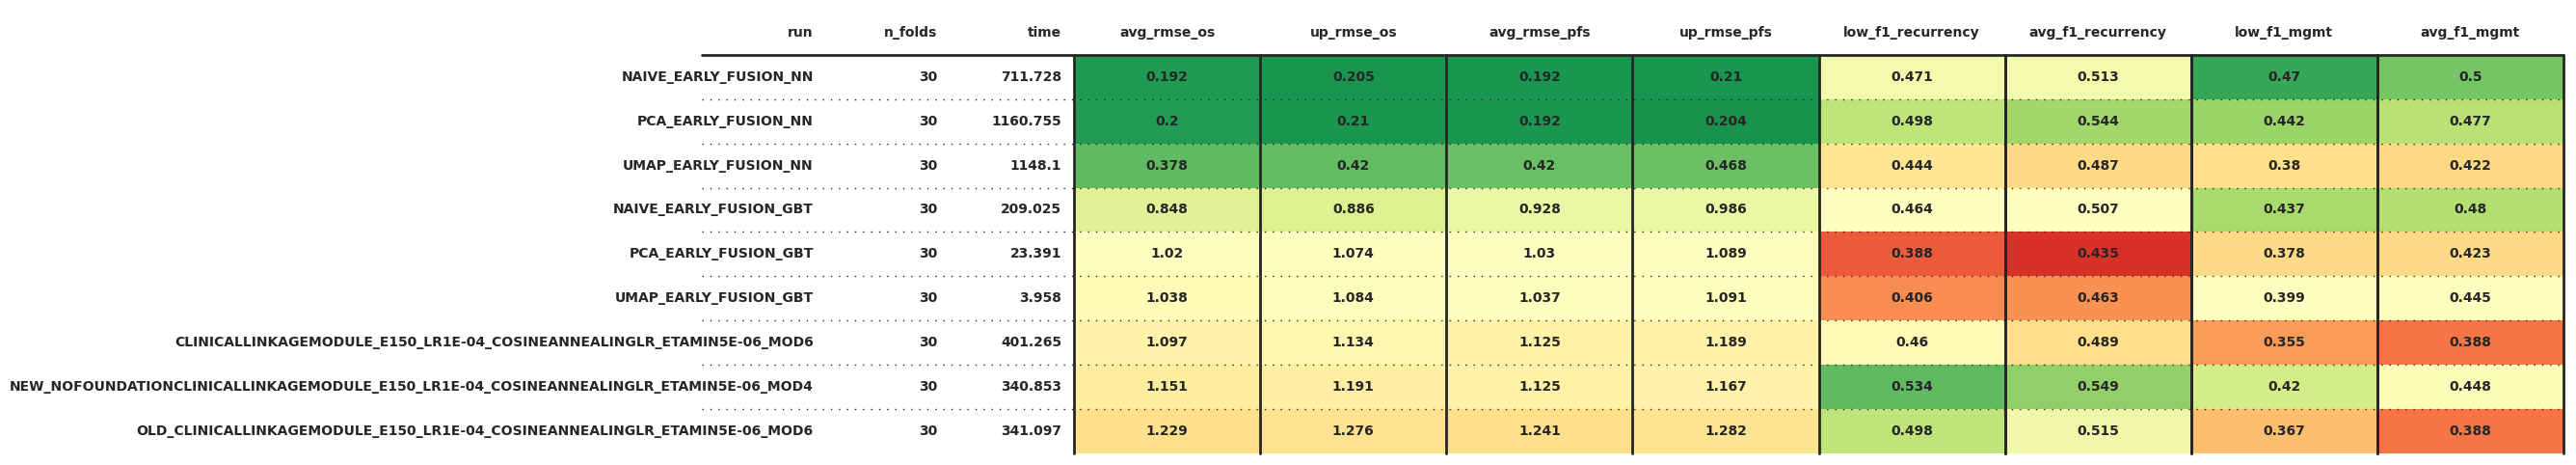

In [30]:
plot_cv_table('../results/cv_results.csv', save=True, out_file="results/cv_results_table.pdf")

## Save ClinicalLinkageModule

In [31]:
save_model(clm, '../saved_models/new_noFoundation_clm.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/new_noFoundation_clm.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_noFoundation_clm.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


(PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/new_noFoundation_clm.ckpt'),
 PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_noFoundation_clm.ckpt'))